In [90]:
import numpy as np

from bqskit import compile, MachineModel
from bqskit.qis import StateVector, StateSystem
from bqskit.ir.gates import CNOTGate, U3Gate, CZGate
import sys
from pathlib import Path

In [91]:
_here = Path().resolve()
for _p in [_here, *_here.parents]:
    _src = _p / "src"
    if (_src / "qudits_on_qubits" / "__init__.py").is_file():
        repo_root = _p
        if str(_src) not in sys.path:
            sys.path.insert(0, str(_src))
        break
else:
    raise ImportError(
        "qudits_on_qubits repo root not found; run the notebook from notebooks/ or the repo root"
    )

In [92]:
from qiskit import qpy

In [93]:
selected_candidate = "baseline__E_old"
#QuditsOnQubits\artifacts\iqm_runs\selected_best\two_qutrit\stage2_top10_rerun20_20260706\exact\rank01_monomial_full__sup023_P012_ph022
artifact_circuit_dir = repo_root / "artifacts" / "iqm_runs" / "raw" / "quantum_circuits" / "garnet" / "two_qutrit_qpy15" / selected_candidate
legacy_circuit_dir = repo_root.parent / "QuditsOnQubits" / "basis_direct_encoding_benchmarks" / "quantum_circuits" / "two_qutrit_qpy15" / selected_candidate
#C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\garnet\two_qutrit_qpy15\baseline__E_oldfor circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
for circuit_dir in (artifact_circuit_dir, legacy_circuit_dir):
    if (circuit_dir / "graph_state_direct_basis.qpy").is_file():
        break
else:
    raise FileNotFoundError(
        "Circuit artifacts not found. Checked:\n"
        f"- {artifact_circuit_dir}\n"
        f"- {legacy_circuit_dir}"
    )

print(f"Loading circuits from: {circuit_dir}")

with (circuit_dir / "graph_state_direct_basis.qpy").open("rb") as f:
    testqc = qpy.load(f)[0]

with (circuit_dir / "graph_state_direct_basis_transpiled.qpy").open("rb") as f:
    qcsuptrans = qpy.load(f)[0]

with (circuit_dir / "F3_W.qpy").open("rb") as f:
    F3sup = qpy.load(f)[0]

with (circuit_dir / "CZ3_W.qpy").open("rb") as f:
    CZ3sup = qpy.load(f)[0]

Esup = np.load(circuit_dir / "E.npy")

Loading circuits from: C:\Users\szymo\QuditsOnQubits\QuditsOnQubits\artifacts\iqm_runs\raw\quantum_circuits\garnet\two_qutrit_qpy15\baseline__E_old


In [94]:
B = Esup

In [95]:
from qiskit.quantum_info import Operator, Statevector
CZ3 = Operator(CZ3sup).data

In [96]:
CZ3.shape

(16, 16)

In [97]:
np.kron(B, B).shape

(16, 9)

In [98]:
omega = np.exp(2j * np.pi / 3)

CZ3_logical = np.diag([
    1, 1, 1,
    1, omega, omega**2,
    1, omega**2, omega
])

In [99]:
B2 = np.kron(B, B)
target_states = B2 @ CZ3_logical

system = {}

for j in range(9):
    input_state = StateVector(B2[:, j], radixes=[2, 2, 2, 2])
    output_state = StateVector(
        target_states[:, j],
        radixes=[2, 2, 2, 2],
    )

    system[input_state] = output_state

target = StateSystem(system)

In [100]:
model = MachineModel(
    4,
    gate_set={
        U3Gate(),
        CZGate(),
    },
)

In [ ]:
compiled = compile(
    target,
    model=model,
    optimization_level=2,
    max_synthesis_size=4,
    synthesis_epsilon=1e-8,
    seed=5,
)

In [ ]:
compiled

Circuit(4)
	[None, None, U3Gate([np.float64(1.570796660652263), np.float64(5.297650334954889), np.float64(3.6844828771406952)])@(2,), U3Gate([np.float64(4.7123887095988755), np.float64(1.8931826545821362), np.float64(1.7214347858157875)])@(3,)]
	[CZGate@(0, 3), CZGate@(1, 2), CZGate@(1, 2), CZGate@(0, 3)]
	[U3Gate([np.float64(1.5286160098301846e-12), np.float64(5.551813438734251), np.float64(5.967359548791074)])@(0,), None, U3Gate([np.float64(1.5707961861762858), np.float64(5.7947592684579075), np.float64(4.127127805522018)])@(2,), U3Gate([np.float64(4.188790054594729), np.float64(6.575280614333394), np.float64(-0.32238623866013777)])@(3,)]
	[None, None, CZGate@(2, 3), CZGate@(2, 3)]
	[None, None, None, U3Gate([np.float64(1.0471971211803441), np.float64(-0.39290840186855563), np.float64(5.9910901956748)])@(3,)]
	[CZGate@(0, 3), None, None, CZGate@(0, 3)]
	[None, None, None, U3Gate([np.float64(3.1415927851830783), np.float64(5.686257968366814), np.float64(5.628896049115325)])@(3,)]
	[No

In [ ]:
from bqskit.ext import bqskit_to_qiskit

qc = bqskit_to_qiskit(compiled)

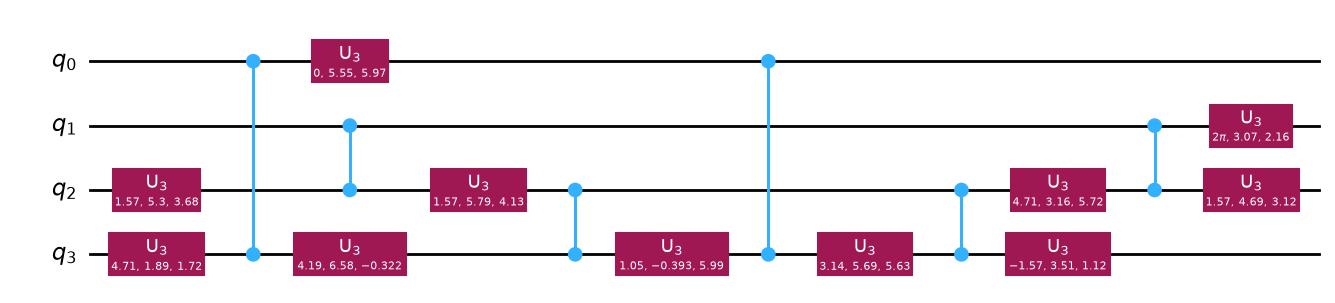

In [ ]:
qc.draw("mpl")

In [ ]:
import numpy as np

U_out = Operator(qc).data

target = B2 @ CZ3_logical
actual = U_out @ B2

# 1. Zwykły błąd na podprzestrzeni kodowej
E = np.linalg.norm(actual - target, ord='fro')


# 2. Błąd na podprzestrzeni kodowej z ignorowaniem globalnej fazy
overlap = np.vdot(actual, target)

if np.abs(overlap) > 1e-15:
    phase = np.exp(1j * np.angle(overlap))
else:
    phase = 1.0

E_code = np.linalg.norm(phase * actual - target, ord='fro')


# 3. Leakage poza code space
P = B2 @ B2.conj().T

L = np.linalg.norm(
    (np.eye(16) - P) @ actual,
    ord='fro'
)

In [ ]:
E_code, E, L

(np.float64(1.4566641474702448e-06),
 np.float64(1.4608567139446699e-06),
 np.float64(6.417337307118899e-07))

In [ ]:
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator

display(
    array_to_latex(
        Operator(qc).data.round(2),
        max_size=16
    )
)

<IPython.core.display.Latex object>

In [ ]:
display(Operator(CZ3sup).draw("latex", max_size=16))

<IPython.core.display.Latex object>

In [ ]:
from qiskit import QuantumCircuit

In [ ]:
twoqutrit = QuantumCircuit(4)
twoqutrit.append(F3sup, [0, 1])
twoqutrit.append(F3sup, [2, 3])
# Use the explicit BQSKit circuit (6 CZ), not CZ3sup's dense 4-qubit unitary.
# Keep its gate structure: converting qc to Operator/UnitaryGate would resynthesize it.
twoqutrit.compose(qc, qubits=[0, 1, 2, 3], inplace=True)
#twoqutrit.append(F3sup.inverse(), [0, 1])

In [ ]:
Statevector(twoqutrit).draw("latex")

In [ ]:
print("BQSKit CZ3:", dict(qc.count_ops()), "depth:", qc.depth())
print("Before IQM (F3 blocks still opaque):", dict(twoqutrit.count_ops()),
      "depth:", twoqutrit.depth())

In [ ]:
twoqutrit.draw("mpl")

In [ ]:
from qiskit import transpile
from qudits_on_qubits.benchmarks.direct_basis.circuit_serialization import (
    normalize_circuit_bit_indices,
)
from qudits_on_qubits.benchmarks.direct_basis.iqm_backend import (
    EXACT_RZ_SCHEDULING_METHOD,
    load_iqm_backend,
)

# This is an unmeasured circuit: preserve terminal RZ rotations.
# Compare unitaries up to global phase and numerical compilation tolerance.
# The Bell benchmark helper uses defaults intended for final computational readout.
iqm_backend = load_iqm_backend("garnet", use_metrics=True)

In [ ]:
twoqutrit_iqm = transpile(
    twoqutrit,
    backend=iqm_backend,
    optimization_level=3,
    seed_transpiler=907,
    scheduling_method=EXACT_RZ_SCHEDULING_METHOD,
    num_processes=1,
)
# Retain the IQM bit-index cache repair used by the benchmark helper.
twoqutrit_iqm = normalize_circuit_bit_indices(twoqutrit_iqm)

In [ ]:
# depth() counts sequential layers, not gates. Report both.
{
    "count_ops": dict(twoqutrit_iqm.count_ops()),
    "CZ": int(twoqutrit_iqm.count_ops().get("cz", 0)),
    "total_gates": twoqutrit_iqm.size(),
    "depth": twoqutrit_iqm.depth(),
}